# Pipeline de Predição de Risco Escolar


In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [2]:
def limpar_colunas(df):
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()]
    return df

def padronizar(df, ano):
    df = limpar_colunas(df)

    col_inde = [
        c for c in df.columns
        if "INDE" in c and (str(ano)[-2:] in c or str(ano) in c)
    ]
    df["INDE"] = df[col_inde[0]] if col_inde else None

    mapa = {
        "Nome": "NOME",
        "Nome Anonimizado": "NOME",
        "Gênero": "SEXO",
        "Idade 22": "IDADE",
        "Idade": "IDADE",
        "Rec Psicologia": "REC_PSICO",
        "Rec Psicologia ": "REC_PSICO",
        "Rec Psicologia.": "REC_PSICO",
        "IAN": "IAN",
        "IDA": "IDA",
        "IEG": "IEG",
        "IAA": "IAA",
        "IPS": "IPS",
        "IPP": "IPP",
        "IPV": "IPV",
        "Defas": "DEFASAGEM",
        "Defasagem": "DEFASAGEM",
        "Destaque IEG": "DESTAQUE_IEG",
        "Destaque IDA": "DESTAQUE_IDA",
    }

    df = df.rename(columns=mapa)

    COLS = [
        "RA", "NOME", "SEXO", "IDADE", "DEFASAGEM", "REC_PSICO",
        "IAN", "IDA", "IEG", "IAA",
        "IPS", "IPP", "IPV", "INDE",
        "DESTAQUE_IEG", "DESTAQUE_IDA"
    ]

    for col in COLS:
        if col not in df.columns:
            df[col] = None

    df = df[COLS].copy()
    df["ANO"] = ano
    return df

In [3]:
arquivo = r"/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2022"), 2022)
df_2023 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2023"), 2023)
df_2024 = padronizar(pd.read_excel(arquivo, sheet_name="PEDE2024"), 2024)

df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)
df.head()

/tmp/ipython-input-471/3413081485.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)


,RA,NOME,SEXO,IDADE,DEFASAGEM,REC_PSICO,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,DESTAQUE_IEG,DESTAQUE_IDA,ANO
0,RA-1,Aluno-1,Menina,19,-1,Requer avaliação,5.0,4.0,4.1,8.3,5.6,NaN,7.278,5.783,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
1,RA-2,Aluno-2,Menina,17,0,Sem limitações,10.0,6.8,5.2,8.8,6.3,NaN,6.778,7.055,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
2,RA-3,Aluno-3,Menina,17,0,Sem limitações,10.0,5.6,7.9,0.0,5.6,NaN,7.556,6.591,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
3,RA-4,Aluno-4,Menino,17,0,Requer avaliação,10.0,5.0,4.5,8.8,5.6,NaN,5.278,5.951,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022
4,RA-5,Aluno-5,Menina,17,0,Requer avaliação,10.0,5.2,8.6,7.9,5.6,NaN,7.389,7.427,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,2022


In [4]:
cols = ['IDADE','DEFASAGEM','IAN','IDA','IEG','IAA','IPS','IPP','IPV','INDE', 'ANO']

# verifica se as colunas possuem algum valor que não sejam números
for c in cols:
    erro = pd.to_numeric(df[c], errors='coerce').isna() & df[c].notna()
    print(c, "-> valores inválidos:", erro.sum(), "-> valor identificado: ", df.loc[erro, c].unique())

IDADE -> valores inválidos: 399 -> valor identificado:  [datetime.datetime(1900, 1, 8, 0, 0) datetime.datetime(1900, 1, 7, 0, 0)
 datetime.datetime(1900, 1, 11, 0, 0) datetime.datetime(1900, 1, 9, 0, 0)
 datetime.datetime(1900, 1, 10, 0, 0) datetime.datetime(1900, 1, 14, 0, 0)
 datetime.datetime(1900, 1, 13, 0, 0) datetime.datetime(1900, 1, 12, 0, 0)
 datetime.datetime(1900, 1, 15, 0, 0) datetime.datetime(1900, 1, 17, 0, 0)
 datetime.datetime(1900, 1, 16, 0, 0) datetime.datetime(1900, 1, 19, 0, 0)
 datetime.datetime(1900, 1, 18, 0, 0) datetime.datetime(1900, 1, 20, 0, 0)
 datetime.datetime(1900, 1, 21, 0, 0) datetime.datetime(1900, 1, 26, 0, 0)]
DEFASAGEM -> valores inválidos: 0 -> valor identificado:  []
IAN -> valores inválidos: 0 -> valor identificado:  []
IDA -> valores inválidos: 0 -> valor identificado:  []
IEG -> valores inválidos: 0 -> valor identificado:  []
IAA -> valores inválidos: 0 -> valor identificado:  []
IPS -> valores inválidos: 0 -> valor identificado:  []
IPP -> val

In [5]:
# Converte para NaN os valores incorretos da coluna INDE
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')
# Converte para NaN os valores incorretos da coluna IDADE
df['IDADE'] = pd.to_numeric(df['IDADE'], errors='coerce')

In [6]:
df["SEXO"].unique()

array(['Menina', 'Menino', 'Feminino', 'Masculino'], dtype=object)

In [7]:
#padroniza a coluna sexo
mapa_sexo = {
    "Menina": "F",
    "Feminino": "F",
    "Menino": "M",
    "Masculino": "M"
}

df["SEXO"] = df["SEXO"].map(mapa_sexo)

In [8]:
df["SEXO"].value_counts()

,count
SEXO,
F,1626
M,1404


In [9]:
#converte para números para usar a coluna sexo como feature no modelo
df["SEXO"] = df["SEXO"].map({"F": 0, "M": 1})

# ✅ Features do texto (simples e fortes)
texto_cols = ["DESTAQUE_IEG", "DESTAQUE_IDA"]

# flag: existe observação?
df["tem_alerta_IEG"] = df["DESTAQUE_IEG"].notna().astype(int)
df["tem_alerta_IDA"] = df["DESTAQUE_IDA"].notna().astype(int)

# flag: contém "melhor" (ajuste palavras se quiser)
df["melhorar_IEG"] = df["DESTAQUE_IEG"].astype(str).str.contains("melhor", case=False, na=False).astype(int)
df["melhorar_IDA"] = df["DESTAQUE_IDA"].astype(str).str.contains("melhor", case=False, na=False).astype(int)

palavras_risco = [
    "melhor", "aten", "dific", "baixo",
    "insuf", "refor", "falta", "ausen", "pend"
]

df["alerta_texto"] = (
    df["DESTAQUE_IEG"].astype(str).str.lower().apply(
        lambda x: any(p in x for p in palavras_risco)
    )
).astype(int)


cols_num = ["IDADE","DEFASAGEM","IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]

df[cols_num] = df[cols_num].apply(pd.to_numeric, errors="coerce")
df[cols_num] = df[cols_num].fillna(df[cols_num].median(numeric_only=True))

df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")

In [10]:
df = df.sort_values(["RA", "ANO"])

df["delta_IDA"] = df.groupby("RA")["IDA"].diff()
df["delta_INDE"] = df.groupby("RA")["INDE"].diff()

df["trend_IDA"] = (
    df.groupby("RA")["delta_IDA"]
      .transform(lambda x: x.rolling(2).mean())
)

df["trend_INDE"] = (
    df.groupby("RA")["delta_INDE"]
      .transform(lambda x: x.rolling(2).mean())
)

df["media_IDA"] = (
    df.groupby("RA")["IDA"]
      .transform(lambda x: x.expanding().mean())
)

df["media_INDE"] = (
    df.groupby("RA")["INDE"]
      .transform(lambda x: x.expanding().mean())
)

In [11]:
# novas features fortes
df["quedas_consecutivas"] = (
    df.groupby("RA")["delta_INDE"]
      .transform(lambda x: (x < 0).rolling(2).sum())
)

df["volatilidade"] = df.groupby("RA")["INDE"].transform("std")

df["risco"] = (df["delta_INDE"] < -1).astype(int)

df_shift = df.sort_values(["RA", "ANO"]).copy()
df_shift["risco_futuro"] = df_shift.groupby("RA")["risco"].shift(-1)

df_model = df_shift.dropna(subset=["risco_futuro"]).copy()
df_model["risco_futuro"] = df_model["risco_futuro"].astype(int)

# ✅ Features de Psicologia (2022 tem, outros anos podem não ter)
df_model["REC_PSICO"] = df_model["REC_PSICO"].fillna("Não avaliado").astype(str).str.strip()

mapa_psico_nivel = {
    "Sem limitações": 0,
    "Não indicado": 0,
    "Não avaliado": 0,
    "Requer avaliação": 1,
    "Não atendido": 2,
}

df_model["psico_nivel"] = df_model["REC_PSICO"].map(mapa_psico_nivel).fillna(0).astype(int)

# flags opcionais (bem úteis)
df_model["psico_requer_avaliacao"] = (df_model["REC_PSICO"] == "Requer avaliação").astype(int)
df_model["psico_nao_atendido"] = (df_model["REC_PSICO"] == "Não atendido").astype(int)

In [12]:
features = [
    "SEXO", "IDADE", "DEFASAGEM",
    "IAN", "IDA", "IEG", "IAA",
    "IPS", "IPP", "IPV",
    "delta_IDA", "trend_IDA", "media_IDA",
    "quedas_consecutivas", "volatilidade",
    "tem_alerta_IEG", "tem_alerta_IDA",
    "melhorar_IEG", "melhorar_IDA",
    "alerta_texto",
    "psico_nivel", "psico_requer_avaliacao", "psico_nao_atendido",
]

train_anos = [2022]
test_ano = 2023

# garante que todas existem
for f in features:
    if f not in df_model.columns:
        df_model[f] = 0

# garante numérico
df_model[features] = df_model[features].apply(pd.to_numeric, errors="coerce")

X_train = df_model[df_model["ANO"].isin(train_anos)][features].fillna(-1)
y_train = df_model[df_model["ANO"].isin(train_anos)]["risco_futuro"]

X_test  = df_model[df_model["ANO"] == test_ano][features].fillna(-1)
y_test  = df_model[df_model["ANO"] == test_ano]["risco_futuro"]


In [13]:
def avaliar_modelo(model, X_train, y_train, X_test, y_test, limiar=0.25):
    model.fit(X_train, y_train)

    if len(getattr(model, "classes_", [])) < 2:
        print("⚠️ Treino ficou com 1 classe só:", model.classes_)
        print("Distribuição y_train:\n", y_train.value_counts())
        return None

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > limiar).astype(int)

    print("=== Classification Report ===")
    print(classification_report(y_test, y_pred))
    print("\nROC AUC:", roc_auc_score(y_test, y_prob))
    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    return y_prob



In [14]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

y_prob_rf = avaliar_modelo(rf, X_train, y_train, X_test, y_test, limiar=0.25)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.87      0.91       676
           1       0.42      0.74      0.54        89

    accuracy                           0.85       765
   macro avg       0.69      0.80      0.72       765
weighted avg       0.90      0.85      0.87       765


ROC AUC: 0.9170018615783525

Matriz de confusão:
[[585  91]
 [ 23  66]]


In [15]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

y_prob_xgb = avaliar_modelo(xgb, X_train, y_train, X_test, y_test, limiar=0.25)

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       676
           1       0.39      0.61      0.48        89

    accuracy                           0.85       765
   macro avg       0.67      0.74      0.69       765
weighted avg       0.88      0.85      0.86       765


ROC AUC: 0.8988597832590919

Matriz de confusão:
[[593  83]
 [ 35  54]]


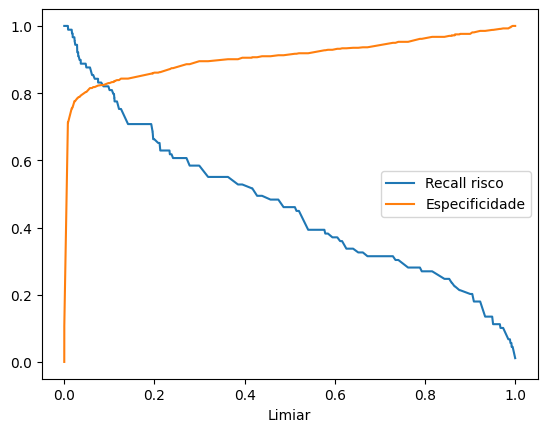

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.plot(thresholds, tpr, label="Recall risco")
plt.plot(thresholds, 1-fpr, label="Especificidade")
plt.xlabel("Limiar")
plt.legend()
plt.show()

In [17]:
df_test = df_model[df_model["ANO"] == test_ano].copy()

X_test_alinhado = df_test[features].fillna(0)

df_test["prob"] = xgb.predict_proba(X_test_alinhado)[:, 1]

top = df_test.sort_values("prob", ascending=False).head(30)

print("Quantos riscos reais no TOP 30?")
print(top["risco_futuro"].sum())

Quantos riscos reais no TOP 30?
17


In [18]:
if y_prob_xgb is not None:
    df_test = df_model[df_model["ANO"] == test_ano].copy()
    X_test_alinhado = df_test[features].fillna(0)

    df_test["prob"] = xgb.predict_proba(X_test_alinhado)[:, 1]

    top30 = df_test.sort_values("prob", ascending=False).head(30)
    print("Quantos riscos reais no TOP 30?", int(top30["risco_futuro"].sum()))

    for k in [10, 20, 30, 50, 100]:
        topk = df_test.sort_values("prob", ascending=False).head(k)
        acertos = int(topk["risco_futuro"].sum())
        print(f"Top {k}: {acertos} acertos → {(acertos/k):.2%}")

Quantos riscos reais no TOP 30? 17
Top 10: 6 acertos → 60.00%
Top 20: 12 acertos → 60.00%
Top 30: 17 acertos → 56.67%
Top 50: 24 acertos → 48.00%
Top 100: 41 acertos → 41.00%


In [19]:
df_2024 = df[df["ANO"] == 2024].copy()

# garante numéricos no 2024 também
df_2024[cols_num] = df_2024[cols_num].apply(pd.to_numeric, errors="coerce")
med_train = df_model[df_model["ANO"].isin(train_anos)][cols_num].median(numeric_only=True)
df_2024[cols_num] = df_2024[cols_num].fillna(med_train)

# garante que todas as features existam no 2024
for f in features:
    if f not in df_2024.columns:
        df_2024[f] = 0

X_2024 = df_2024[features].fillna(0)
df_2024["prob"] = xgb.predict_proba(X_2024)[:, 1]

In [20]:
df_test.to_parquet(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_validacao.parquet")
df_test.to_csv(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_final.csv")
df_2024.to_parquet(r"C:\Users\gabri\Desktop\FIAP\Fase_5\Tech_Challenge\data\base_2024_pred.parquet")

In [21]:
df_2024.columns

Index(['RA', 'NOME', 'SEXO', 'IDADE', 'DEFASAGEM', 'REC_PSICO', 'IAN', 'IDA',
       'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'DESTAQUE_IEG',
       'DESTAQUE_IDA', 'ANO', 'tem_alerta_IEG', 'tem_alerta_IDA',
       'melhorar_IEG', 'melhorar_IDA', 'alerta_texto', 'delta_IDA',
       'delta_INDE', 'trend_IDA', 'trend_INDE', 'media_IDA', 'media_INDE',
       'quedas_consecutivas', 'volatilidade', 'risco', 'psico_nivel',
       'psico_requer_avaliacao', 'psico_nao_atendido', 'prob'],
      dtype='object')

In [24]:
df["ANO"].unique()

<IntegerArray>
[2022, 2023, 2024]
Length: 3, dtype: Int64

In [25]:
df.columns

Index(['RA', 'NOME', 'SEXO', 'IDADE', 'DEFASAGEM', 'REC_PSICO', 'IAN', 'IDA',
       'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'DESTAQUE_IEG',
       'DESTAQUE_IDA', 'ANO', 'tem_alerta_IEG', 'tem_alerta_IDA',
       'melhorar_IEG', 'melhorar_IDA', 'alerta_texto', 'delta_IDA',
       'delta_INDE', 'trend_IDA', 'trend_INDE', 'media_IDA', 'media_INDE',
       'quedas_consecutivas', 'volatilidade', 'risco'],
      dtype='object')

In [28]:
import pandas as pd
import numpy as np

indicadores = ["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]

df = df.copy()

# Tipos
df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")

for c in indicadores + ["delta_IDA","delta_INDE","media_IDA","media_INDE","volatilidade"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# (opcional) remover linhas sem ano
df = df.dropna(subset=["ANO"])

In [32]:
df["ANO"] = pd.to_numeric(df["ANO"], errors="coerce")
df = df.dropna(subset=["ANO"])
df["ANO"] = df["ANO"].astype(int)

In [35]:
df["ANO"].unique()

array([2022, 2023, 2024])

In [36]:
df["ANO"] = df["ANO"].astype(str)

In [37]:
import plotly.express as px
import numpy as np

# Exemplo: faixas por quantis (ajuste se tiver regra oficial)
q1, q2 = df["IAN"].quantile([0.33, 0.66])
df["faixa_IAN"] = pd.cut(
    df["IAN"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Severamente defasado", "Moderadamente defasado", "Sem/leve defasagem"]
)

# Perfil geral
fig1 = px.histogram(df, x="IAN", nbins=30, title="Distribuição do IAN (perfil geral)")
fig1.show()

# Evolução anual (média)
ian_ano = df.groupby("ANO", as_index=False)["IAN"].mean()
fig2 = px.line(ian_ano, x="ANO", y="IAN", markers=True, title="IAN médio por ano")
fig2.show()

# Barras empilhadas por ano
dist = (df.groupby(["ANO","faixa_IAN"]).size().reset_index(name="qtd"))
dist["pct"] = dist["qtd"] / dist.groupby("ANO")["qtd"].transform("sum")
fig3 = px.bar(dist, x="ANO", y="pct", color="faixa_IAN", barmode="stack",
              title="Proporção de alunos por faixa de IAN (por ano)")
fig3.show()

/tmp/ipython-input-471/248011932.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [38]:
ida_ano = df.groupby("ANO", as_index=False)["IDA"].mean()
px.line(ida_ano, x="ANO", y="IDA", markers=True, title="IDA médio por ano").show()

px.box(df, x="ANO", y="IDA", title="Distribuição do IDA por ano").show()

if "trend_IDA" in df.columns:
    t = df.groupby(["ANO","trend_IDA"]).size().reset_index(name="qtd")
    px.bar(t, x="ANO", y="qtd", color="trend_IDA", barmode="group",
           title="Tendência do IDA (trend_IDA) por ano").show()

In [39]:
px.scatter(df, x="IEG", y="IDA", trendline="ols", hover_data=["RA","NOME","ANO"],
           title="IEG vs IDA (correlação)").show()

px.scatter(df, x="IEG", y="IPV", trendline="ols", hover_data=["RA","NOME","ANO"],
           title="IEG vs IPV (correlação)").show()

corr_ano = (df.groupby("ANO")
              .apply(lambda g: g["IEG"].corr(g["IDA"]))
              .reset_index(name="corr_IEG_IDA"))
px.line(corr_ano, x="ANO", y="corr_IEG_IDA", markers=True,
        title="Correlação IEG x IDA por ano").show()

/tmp/ipython-input-471/302996934.py:8: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [40]:
px.scatter(df, x="IAA", y="IDA", trendline="ols", hover_data=["RA","NOME","ANO"],
           title="IAA vs IDA (coerência)").show()

px.scatter(df, x="IAA", y="IEG", trendline="ols", hover_data=["RA","NOME","ANO"],
           title="IAA vs IEG (coerência)").show()

corr = df[["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE"]].corr()
px.imshow(corr, text_auto=True, title="Correlação entre indicadores").show()

In [41]:
df["teve_queda_IDA"] = (df["delta_IDA"] < 0)

px.box(df, x="teve_queda_IDA", y="IPS",
       title="IPS vs ocorrência de queda no IDA (delta_IDA < 0)").show()

px.scatter(df, x="IPS", y="delta_IDA", trendline="ols",
           title="IPS vs delta_IDA").show()

# Probabilidade de queda por quantil de IPS
df["q_ips"] = pd.qcut(df["IPS"], 10, duplicates="drop")
p = df.groupby("q_ips", as_index=False)["teve_queda_IDA"].mean()
px.line(p, x="q_ips", y="teve_queda_IDA", markers=True,
        title="Probabilidade de queda no IDA por faixa (quantil) de IPS").show()

/tmp/ipython-input-471/1909172542.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



TypeError: Type is not JSON serializable: pandas._libs.interval.Interval

In [42]:
px.scatter(df, x="IAN", y="IPP", trendline="ols",
           title="IAN vs IPP (confirmação/contradição)").show()

med_ian = df["IAN"].median()
med_ipp = df["IPP"].median()

df["ian_bin"] = np.where(df["IAN"] >= med_ian, "IAN alto", "IAN baixo")
df["ipp_bin"] = np.where(df["IPP"] >= med_ipp, "IPP alto", "IPP baixo")
quad = df.groupby(["ian_bin","ipp_bin"]).size().reset_index(name="qtd")

px.bar(quad, x="ian_bin", y="qtd", color="ipp_bin", barmode="group",
       title="Quadrantes IAN x IPP").show()

px.density_heatmap(df, x="IAN", y="IPP", nbinsx=25, nbinsy=25,
                   title="Densidade IAN x IPP").show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance

feat = ["IAN","IDA","IEG","IAA","IPS","IPP","INDE"]  # ajuste se quiser tirar INDE
data = df.dropna(subset=feat+["IPV"]).copy()

X = data[feat]
y = data["IPV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestRegressor(n_estimators=400, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("R2:", r2_score(y_test, pred))

imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({"feature": feat, "importance": imp.importances_mean}).sort_values("importance", ascending=False)

px.bar(imp_df, x="importance", y="feature", orientation="h",
       title="Importância das variáveis para explicar IPV (permutation importance)").show()

R2: 0.7444154946312338


In [44]:
cols = ["IDA","IEG","IPS","IPP","INDE"]
d = df.dropna(subset=cols).copy()

# Quantis e média do INDE
for c in ["IDA","IEG","IPS","IPP"]:
    d[f"q_{c}"] = pd.qcut(d[c], 4, labels=["Q1","Q2","Q3","Q4"], duplicates="drop")

grp = d.groupby(["q_IDA","q_IEG","q_IPS","q_IPP"], as_index=False)["INDE"].mean()
top = grp.sort_values("INDE", ascending=False).head(15)
print(top)

# Parallel Coordinates (amostra pra não pesar)
sample = d.sample(min(len(d), 1000), random_state=42)
px.parallel_coordinates(sample, dimensions=["IDA","IEG","IPS","IPP","INDE"],
                        title="Padrões multidimensionais (amostra)").show()

ValueError: Bin labels must be one fewer than the number of bin edges

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Features candidatas
features = ["IAN","IDA","IEG","IAA","IPS","IPP","IPV","INDE",
            "delta_IDA","delta_INDE","quedas_consecutivas","volatilidade",
            "tem_alerta_IEG","tem_alerta_IDA","melhorar_IEG","melhorar_IDA",
            "media_IDA","media_INDE"]

# mantém só as que existem
features = [c for c in features if c in df.columns]

data = df.dropna(subset=["risco"]).copy()

# garante 0/1
y = data["risco"]
if y.dtype == "O":
    # tenta mapear strings comuns
    y = y.astype(str).str.lower().map({"1":1,"0":0,"true":1,"false":0,"sim":1,"nao":0,"não":0})
data["risco_bin"] = y
data = data.dropna(subset=["risco_bin"])

X = data[features]
y = data["risco_bin"].astype(int)

# Split por ano (último ano como teste)
ano_max = int(data["ANO"].max())
train = data[data["ANO"] < ano_max]
test  = data[data["ANO"] == ano_max]

X_train, y_train = train[features], train["risco_bin"].astype(int)
X_test,  y_test  = test[features],  test["risco_bin"].astype(int)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ANO teste:", ano_max)
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# Ranking dos alunos em maior risco no ano de teste
saida = test[["RA","NOME","ANO"]].copy()
saida["prob_risco"] = proba
saida = saida.sort_values("prob_risco", ascending=False)
print(saida.head(20))

TypeError: '<' not supported between instances of 'str' and 'int'

In [46]:
import plotly.express as px
px.histogram(saida, x="prob_risco", nbins=30, title="Distribuição da probabilidade de risco (ano teste)").show()

top20 = saida.head(20).sort_values("prob_risco")
px.bar(top20, x="prob_risco", y="NOME", orientation="h",
       title="Top 20 alunos com maior probabilidade de risco (ano teste)").show()

NameError: name 'saida' is not defined

In [47]:
inde_ano = df.groupby("ANO", as_index=False)["INDE"].mean()
px.line(inde_ano, x="ANO", y="INDE", markers=True, title="INDE médio por ano").show()

ida_ano = df.groupby("ANO", as_index=False)["IDA"].mean()
px.line(ida_ano, x="ANO", y="IDA", markers=True, title="IDA médio por ano").show()

if "risco" in df.columns:
    r = df.dropna(subset=["risco"]).groupby("ANO", as_index=False)["risco"].mean()
    px.line(r, x="ANO", y="risco", markers=True, title="% médio de risco por ano").show()

if "delta_INDE" in df.columns:
    d = df.groupby("ANO", as_index=False)["delta_INDE"].mean()
    px.bar(d, x="ANO", y="delta_INDE", title="Delta INDE médio por ano").show()